# Checking the Bathymetry and the bottom cells

In [1]:
import numpy as np
import xarray as xr

In [2]:
Hgr = "Hgr_cmesh.nc"
Zgr = "Zgr_cmesh2.nc"

In [3]:
hgr = xr.open_dataset(Hgr).compute()
zgr = xr.open_dataset(Zgr).compute()

In [4]:
hgr

<xarray.Dataset> Size: 70MB
Dimensions:       (y: 499, x: 1260, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/21)
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lev       (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_counter  (t) float64 8B 0.0
    glamt         (t, y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    glamu         (t, y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.889 9.972
    ...            ...
    e1f           (t, y, x) float64 5MB 9.128e+03 9.128e+03 ... 8.028e+03
    e2t           (t, y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.845e+03
    e2u           (t, y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.845e+03
    e2v           (t, y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.841e+03
    e2f           (t, y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.841e+03
    ff            (t, y, x) float64 5MB -2.51e-05 -2.51e-05 ... 7.288e-05
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [5]:
zgr

<xarray.Dataset> Size: 26MB
Dimensions:       (y: 499, x: 1260, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/13)
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lev       (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_counter  (t) float64 8B 0.0
    mbathy        (t, y, x) int16 1MB 45 45 45 45 45 45 45 45 ... 0 0 0 0 0 0 0
    deptht        (t, y, x) float64 5MB 3.562e+03 3.518e+03 ... 1.541 1.541
    ...            ...
    e3t_ps        (t, y, x) float64 5MB 314.7 225.6 281.7 366.7 ... 0.0 0.0 0.0
    e3w_ps        (t, y, x) float64 5MB 341.5 298.1 325.4 366.8 ... 0.0 0.0 0.0
    gdept_0       (t, z) float64 400B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    gdepw_0       (t, z) float64 400B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
    e3t_0         (t, z) float64 400B 1.022 1.074 1.137 ... 435.1 447.6 458.4
    e3w_0         (t, z) float64 400B 1.0 1.047 1.104 ... 428.1 441.6 453.2
Attributes:
    file_name:            mesh_zgr.nc
    TimeStamp:            03/02/2016 10:24:41 -0000
    Unlimited_Dimension:  t
    history:              Wed Nov  5 17:28:38 2025: ncrename -v hdept,deptht ...
    NCO:                  netCDF Operators version 5.0.6 (Homepage = http://n...

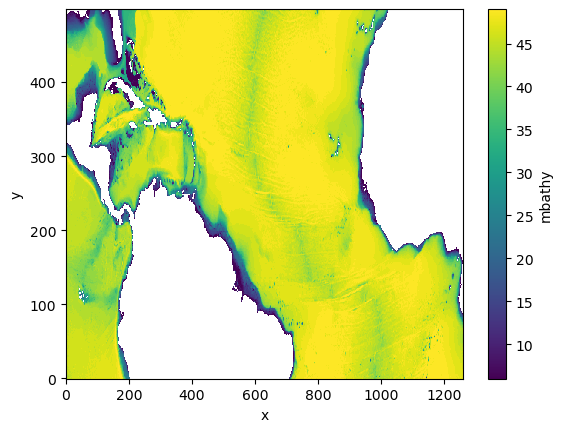

In [13]:
zgr.mbathy.where(zgr.mbathy!=0).plot()

In [28]:
zgr.mbathy

<xarray.DataArray 'mbathy' (t: 1, y: 499, x: 1260)> Size: 1MB
array([[[45, 45, 45, ..., 47, 47, 47],
        [45, 45, 45, ..., 47, 47, 47],
        [45, 46, 46, ..., 47, 47, 47],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]]], shape=(1, 499, 1260), dtype=int16)
Dimensions without coordinates: t, y, x

In [59]:
# zgr = zgr.drop_vars(['t'])
zgr.depthw.where(zgr.depthw!=0)
# zgr.depthw.min()


<xarray.DataArray 'depthw' (y: 499, x: 1260)> Size: 5MB
array([[3.72100000e+03, 3.63200000e+03, 3.68800000e+03, ...,
        4.32400000e+03, 4.29100000e+03, 4.31900000e+03],
       [3.69500000e+03, 3.68700000e+03, 3.79247374e+03, ...,
        4.48000000e+03, 4.43800000e+03, 4.32100000e+03],
       [3.73800000e+03, 3.85600000e+03, 3.86900000e+03, ...,
        4.57000000e+03, 4.52500000e+03, 4.33600000e+03],
       ...,
       [2.08567601e+00, 2.08567601e+00, 2.08567601e+00, ...,
        2.08567601e+00, 2.08567601e+00, 2.08567601e+00],
       [2.08567601e+00, 2.08567601e+00, 2.08567601e+00, ...,
        2.08567601e+00, 2.08567601e+00, 2.08567601e+00],
       [2.08567601e+00, 2.08567601e+00, 2.08567601e+00, ...,
        2.08567601e+00, 2.08567601e+00, 2.08567601e+00]],
      shape=(499, 1260))
Dimensions without coordinates: y, x

---
## The architecture of a NEMO cell

**Horizontal (`mesh_hgr`)** — the Arakawa **C**-grid (hence `cmesh`). Each cell carries 4 points:
`T` centre, `U` east face, `V` north face, `F` corner. Every geometric variable exists in 4 flavours,
one per point: `glam*` = longitude, `gphi*` = latitude, `e1*` = width in x (m), `e2*` = width in y (m).

**Vertical (`mesh_zgr`)** — `gdep*` = depth of a point, `e3*` = thickness of a cell;
`t` = level centre (tracers, U, V), `w` = level interface (W lives here).
`_0` = 1-D reference column, `_ps` = 2-D **partial-step** override at the sea floor.


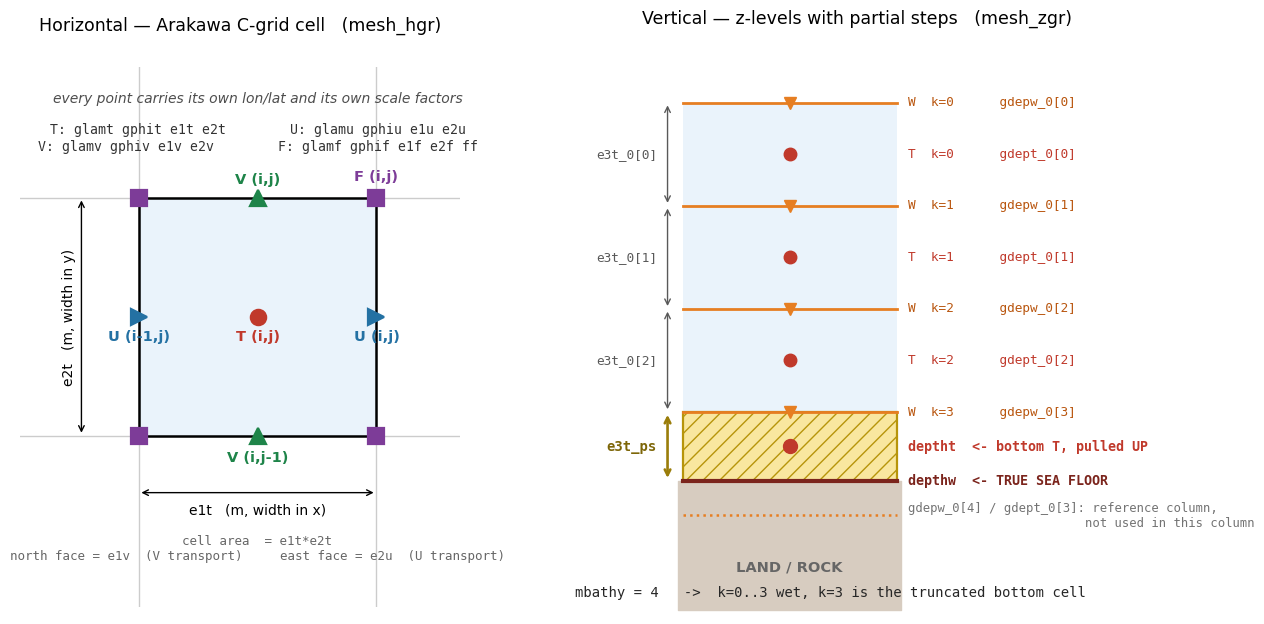

In [60]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14.5, 7.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.22)

# ----------------------------------------------------------------- LEFT: C-grid
ax = fig.add_subplot(gs[0])
ax.set_title("Horizontal — Arakawa C-grid cell   (mesh_hgr)", fontsize=12.5, pad=26)

for i in (0, 1):
    ax.axvline(i, color="0.8", lw=1, zorder=0)
    ax.axhline(i, color="0.8", lw=1, zorder=0)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fc="#eaf3fb", ec="k", lw=1.8, zorder=1))

P = dict(ms=11, mew=1.6, zorder=5, clip_on=False)
ax.plot(.5, .5, "o", c="#c0392b", **P)
ax.plot([0, 1], [.5, .5], ">", c="#2471a3", **P)
ax.plot([.5, .5], [0, 1], "^", c="#1e8449", **P)
ax.plot([0, 0, 1, 1], [0, 1, 0, 1], "s", c="#7d3c98", **P)

lab = dict(ha="center", fontsize=10.5, fontweight="bold")
ax.text(.5, .40, "T (i,j)", color="#c0392b", **lab)
ax.text(1.0, .40, "U (i,j)", color="#2471a3", **lab)
ax.text(.5, 1.06, "V (i,j)", color="#1e8449", **lab)
ax.text(1.0, 1.07, "F (i,j)", color="#7d3c98", **lab)
ax.text(0.0, .40, "U (i-1,j)", color="#2471a3", **lab)
ax.text(.5, -.11, "V (i,j-1)", color="#1e8449", **lab)

ax.annotate("", (0, -.24), (1, -.24), arrowprops=dict(arrowstyle="<->", color="k"))
ax.text(.5, -.33, "e1t   (m, width in x)", ha="center", fontsize=10)
ax.annotate("", (-.24, 0), (-.24, 1), arrowprops=dict(arrowstyle="<->", color="k"))
ax.text(-.32, .5, "e2t   (m, width in y)", va="center", rotation=90, fontsize=10)

ax.text(.5, 1.40, "every point carries its own lon/lat and its own scale factors",
        ha="center", fontsize=10, style="italic", color="0.3")
ax.text(.5, 1.20,
        "T: glamt gphit e1t e2t        U: glamu gphiu e1u e2u\n"
        "V: glamv gphiv e1v e2v        F: glamf gphif e1f e2f ff",
        ha="center", fontsize=9.5, family="monospace", color="0.2")
ax.text(.5, -.52, "cell area  = e1t*e2t\nnorth face = e1v  (V transport)     east face = e2u  (U transport)",
        ha="center", fontsize=9, family="monospace", color="0.4")

ax.set_xlim(-.5, 1.35); ax.set_ylim(-.72, 1.55); ax.set_aspect("equal"); ax.axis("off")

# ----------------------------------------------------------------- RIGHT: vertical
ax = fig.add_subplot(gs[1])
ax.set_title("Vertical — z-levels with partial steps   (mesh_zgr)", fontsize=12.5, pad=26)

gw = [0, 1.2, 2.4, 3.6, 4.8]      # schematic gdepw_0 (interfaces)
gt = [0.6, 1.8, 3.0, 4.2]         # schematic gdept_0 (centres)
xl, xr = 0.0, 1.0
floor = 4.4                       # true sea floor: inside cell k=3

ax.add_patch(plt.Rectangle((xl, 0), xr-xl, floor, fc="#eaf3fb", ec="none", zorder=0))
ax.fill_between([xl-.02, xr+.02], floor, 5.9, color="#d7ccc0", zorder=1)
ax.text((xl+xr)/2, 5.45, "LAND / ROCK", ha="center", fontsize=10.5, color="0.4",
        fontweight="bold", zorder=2)

# full cells k=0..2
for k in range(3):
    ax.plot([xl, xr], [gw[k], gw[k]], "-", c="#e67e22", lw=2, zorder=3)
    ax.plot(.5, gw[k], "v", c="#e67e22", ms=9, zorder=4)
    ax.text(xr+.05, gw[k], f"W  k={k}      gdepw_0[{k}]", va="center", fontsize=9.2,
            color="#b9560f", family="monospace", zorder=4)
    ax.plot(.5, gt[k], "o", c="#c0392b", ms=9, zorder=4)
    ax.text(xr+.05, gt[k], f"T  k={k}      gdept_0[{k}]", va="center", fontsize=9.2,
            color="#c0392b", family="monospace", zorder=4)
    ax.annotate("", (xl-.07, gw[k]), (xl-.07, gw[k+1]),
                arrowprops=dict(arrowstyle="<->", color="0.35"))
    ax.text(xl-.12, (gw[k]+gw[k+1])/2, f"e3t_0[{k}]", va="center", ha="right",
            fontsize=9.2, family="monospace", color="0.35")

# top of bottom cell
ax.plot([xl, xr], [gw[3], gw[3]], "-", c="#e67e22", lw=2, zorder=3)
ax.plot(.5, gw[3], "v", c="#e67e22", ms=9, zorder=4)
ax.text(xr+.05, gw[3], "W  k=3      gdepw_0[3]", va="center", fontsize=9.2,
        color="#b9560f", family="monospace", zorder=4)

# the truncated bottom cell
ax.add_patch(plt.Rectangle((xl, gw[3]), xr-xl, floor-gw[3], fc="#f9e79f", ec="#b7950b",
                           lw=1.6, hatch="//", zorder=2))
ax.annotate("", (xl-.07, gw[3]), (xl-.07, floor),
            arrowprops=dict(arrowstyle="<->", color="#9a7d0a", lw=1.9))
ax.text(xl-.12, (gw[3]+floor)/2, "e3t_ps", va="center", ha="right", fontsize=10,
        family="monospace", color="#7d6608", fontweight="bold")

# what the reference column WOULD have said (now inside the rock)
ax.plot([xl, xr], [gw[4], gw[4]], ":", c="#e67e22", lw=1.8, zorder=3)
ax.text(xr+.05, gw[4], "gdepw_0[4] / gdept_0[3]: reference column,\n"
        "                        not used in this column", va="center", fontsize=8.8,
        color="0.45", family="monospace", zorder=4)

# actual bottom values
ax.plot(.5, (gw[3]+floor)/2, "o", c="#c0392b", ms=10, zorder=6)
ax.text(xr+.05, (gw[3]+floor)/2, "deptht  <- bottom T, pulled UP", va="center",
        fontsize=9.6, family="monospace", color="#c0392b", fontweight="bold", zorder=6)
ax.plot([xl, xr], [floor, floor], "-", c="#7b241c", lw=3, zorder=5)
ax.text(xr+.05, floor, "depthw  <- TRUE SEA FLOOR", va="center", fontsize=9.6,
        family="monospace", color="#7b241c", fontweight="bold", zorder=6)

ax.text(xl-.5, 5.75, "mbathy = 4   ->  k=0..3 wet, k=3 is the truncated bottom cell",
        fontsize=10, color="0.15", family="monospace", zorder=6)

ax.set_xlim(-.52, 2.15); ax.set_ylim(5.95, -.5); ax.axis("off")
plt.show()


---
## Why `zgr.depthw != 0` finds no land

On land NEMO does **not** write 0 into `depthw`. It writes a **placeholder**: the depths a
dummy 2-level column would have had, `gdepw_0[2] = 2.0857` and `gdept_0[1] = 1.5414`.
The code needs finite depths everywhere, so land columns get plausible-looking small numbers.

The mask lives in **`mbathy == 0`** (or equivalently **`e3t_ps == 0`**), never in `depthw`.


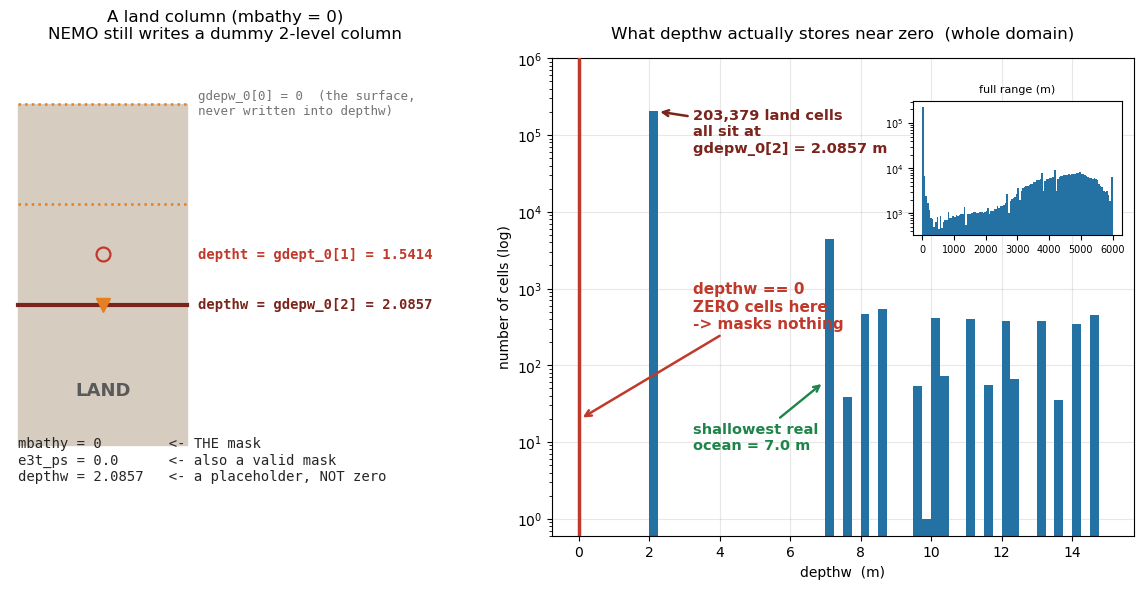

In [61]:
import numpy as np, xarray as xr
import matplotlib.pyplot as plt

_z = xr.open_dataset(Zgr).isel(t=0)   # local copy, does not touch your zgr
land = (_z.mbathy == 0)
dw   = _z.depthw.values
dummy_w, dummy_t = float(_z.gdepw_0[2]), float(_z.gdept_0[1])
nland = int(land.sum())

fig = plt.figure(figsize=(14.5, 6.2))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.22)

# ---------------------------------------------- A: what a land column looks like
ax = fig.add_subplot(gs[0])
ax.set_title("A land column (mbathy = 0)\nNEMO still writes a dummy 2-level column",
             fontsize=12, pad=14)
gw = [0, 1.0, 2.0]
ax.fill_between([0, 1], 0, 3.4, color="#d7ccc0", zorder=0)
ax.text(.5, 2.9, "LAND", ha="center", fontsize=13, color="0.35", fontweight="bold")

for k, d in enumerate(gw):
    ax.plot([0, 1], [d, d], ":", c="#e67e22", lw=1.8, zorder=2)
ax.plot([0, 1], [gw[2], gw[2]], "-", c="#7b241c", lw=3, zorder=3)
ax.plot(.5, gw[2], "v", c="#e67e22", ms=10, zorder=4)
ax.plot(.5, 1.5, "o", mfc="none", mec="#c0392b", ms=10, mew=1.6, zorder=4)

ax.text(1.06, gw[2], f"depthw = gdepw_0[2] = {dummy_w:.4f}", va="center",
        fontsize=10, family="monospace", color="#7b241c", fontweight="bold")
ax.text(1.06, 1.5, f"deptht = gdept_0[1] = {dummy_t:.4f}", va="center",
        fontsize=10, family="monospace", color="#c0392b", fontweight="bold")
ax.text(1.06, 0.0, "gdepw_0[0] = 0  (the surface,\nnever written into depthw)",
        va="center", fontsize=9, family="monospace", color="0.45")
ax.text(0.0, 3.75, f"mbathy = 0        <- THE mask\ne3t_ps = 0.0      <- also a valid mask\ndepthw = {dummy_w:.4f}   <- a placeholder, NOT zero",
        fontsize=10, family="monospace", color="0.15")
ax.set_xlim(-.05, 2.5); ax.set_ylim(4.3, -.45); ax.axis("off")

# ---------------------------------------------- B: histogram, zoomed on 0-15 m
ax = fig.add_subplot(gs[1])
ax.set_title("What depthw actually stores near zero  (whole domain)", fontsize=12, pad=14)
bins = np.arange(0, 15.01, 0.25)
ax.hist(dw.ravel(), bins=bins, color="#2471a3", zorder=2)
ax.set_yscale("log"); ax.set_ylim(0.6, 1e6)
ax.set_xlabel("depthw  (m)"); ax.set_ylabel("number of cells (log)")

ax.axvline(0, color="#c0392b", lw=2.5, zorder=3)
ax.annotate("depthw == 0\nZERO cells here\n-> masks nothing",
            xy=(0.05, 20), xytext=(3.25, 3e2), fontsize=11, color="#c0392b",
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.8))
ax.annotate(f"{nland:,} land cells\nall sit at\ngdepw_0[2] = {dummy_w:.4f} m",
            xy=(dummy_w+0.15, nland), xytext=(3.25, 6e4), fontsize=10.5,
            color="#7b241c", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#7b241c", lw=1.8))
ax.annotate(f"shallowest real\nocean = {float(_z.depthw.where(~land).min()):.1f} m",
            xy=(6.95, 60), xytext=(3.25, 8), fontsize=10.5, color="#1e8449",
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#1e8449", lw=1.7))
ax.grid(alpha=.3, zorder=0)

axi = ax.inset_axes([0.62, 0.63, 0.36, 0.28])
axi.hist(dw.ravel(), bins=np.linspace(0, 6000, 121), color="#2471a3")
axi.set_yscale("log"); axi.tick_params(labelsize=7)
axi.set_title("full range (m)", fontsize=8)
plt.show()


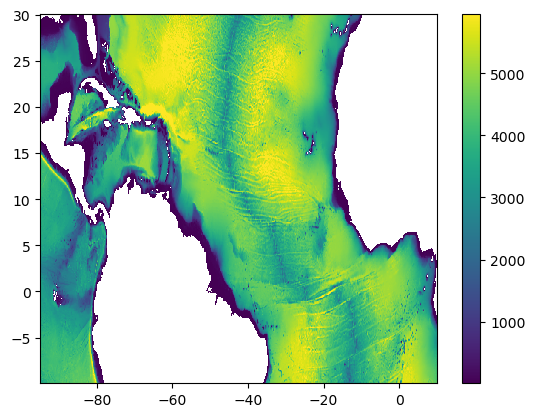

In [46]:
import matplotlib.pyplot as plt
hgr = xr.open_dataset(Hgr).isel(t=0)
zgr = xr.open_dataset(Zgr).isel(t=0)

# land/sea mask, 2D and 3D
land2d = zgr.mbathy == 0
k = xr.DataArray(np.arange(50), dims="z")
tmask = (k < zgr.mbathy)              # (z,y,x) True where wet

# true 3D cell thickness with partial steps
e3t = zgr.e3t_0.broadcast_like(tmask).copy()
bottom = (k == zgr.mbathy - 1)
e3t = xr.where(bottom, zgr.e3t_ps, e3t).where(tmask)

# cell volume, and sea-floor depth
vol   = e3t * hgr.e1t * hgr.e2t
bathy = zgr.depthw.where(~land2d)

# correct plotting with cell corners
plt.pcolormesh(hgr.glamf, hgr.gphif, bathy)   # not glamt/gphit
plt.colorbar()
